In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

%matplotlib inline

In [45]:
df_2020 = pd.read_csv('data/df_2020_mit_labels.csv')
df_2021 = pd.read_csv('data/df_2021_mit_labels.csv')

In [46]:
df_2020 = df_2020.drop(columns=['system:index', 'image_count', '.geo'])
df_2020 = df_2020.fillna(df_2020.mean())

df_2021 = df_2021.drop(columns=['system:index', 'image_count', '.geo'])
df_2021 = df_2021.fillna(df_2021.mean())

In [47]:
mean_median_cols = [col for col in df_2020.columns if ('_mean' in col or '_median' in col)]

all_target_cols = [
    'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
    'herbaceous_wetland', 'mangroves', 'moss_lichen', 'shrubland',
    'snow_ice', 'tree_cover', 'water'
]

selected_labels = [
    'tree_cover', 'built_up',
    # 'grassland', 'cropland',
    # 'bare_sparse_vegetation', 'water'
]

sel_col = mean_median_cols + all_target_cols
df_2020 = df_2020[sel_col]
df_2021 = df_2021[sel_col]

In [48]:
X_train = df_2020.drop(columns=all_target_cols)
y_train = df_2020[selected_labels]

X_test = df_2021.drop(columns=all_target_cols)
y_test = df_2021[selected_labels]

In [49]:
def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"--- {model_name} ---")
    print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}\n")

    return {
        'Model': model_name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    }

In [50]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR

models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]),
    "Ridge Regression": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))]),
    "Lasso Regression": Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(alpha=0.1, max_iter=10000))]),
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", MultiOutputRegressor(SVR(kernel='rbf', C=100, epsilon=0.1)))
    ]),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
}

results = []
for name, model in models.items():
    res = evaluate_regression_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)


--- Linear Regression ---
Train R2: 0.7248 | Test R2: 0.6321
Train RMSE: 0.1888 | Test RMSE: 0.2230

--- Ridge Regression ---
Train R2: 0.7246 | Test R2: 0.6343
Train RMSE: 0.1888 | Test RMSE: 0.2223

--- Lasso Regression ---
Train R2: 0.5142 | Test R2: 0.4796
Train RMSE: 0.2509 | Test RMSE: 0.2660

--- SVR ---
Train R2: 0.9410 | Test R2: 0.6326
Train RMSE: 0.0875 | Test RMSE: 0.2219

--- Random Forest ---
Train R2: 0.9424 | Test R2: 0.6404
Train RMSE: 0.0864 | Test RMSE: 0.2193

--- XGBoost ---
Train R2: 0.9555 | Test R2: 0.6444
Train RMSE: 0.0759 | Test RMSE: 0.2178



In [54]:
summary_df = pd.DataFrame(results).sort_values(by='Test RMSE', ascending=True)
display(summary_df)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
5,XGBoost,0.075912,0.217828,0.955522,0.644358
4,Random Forest,0.086400,0.219265,0.942356,0.640420
3,SVR,0.087473,0.221919,0.940952,0.632572
1,Ridge Regression,0.188843,0.222296,0.724574,0.634292
0,Linear Regression,0.188751,0.223032,0.724842,0.632080
2,Lasso Regression,0.250911,0.265976,0.514154,0.479579


In [52]:
selected_labels = [
    'tree_cover', 'built_up', 'grassland', 'cropland',
    'bare_sparse_vegetation', 'water'
]

pd.DataFrame({'mean': df_2020[selected_labels].mean(), 'std': df_2020[selected_labels].std()})

,mean,std
tree_cover,0.380674,0.364216
built_up,0.353596,0.355716
grassland,0.123147,0.213471
cropland,0.108197,0.257449
bare_sparse_vegetation,0.023480,0.071798
water,0.010726,0.074863


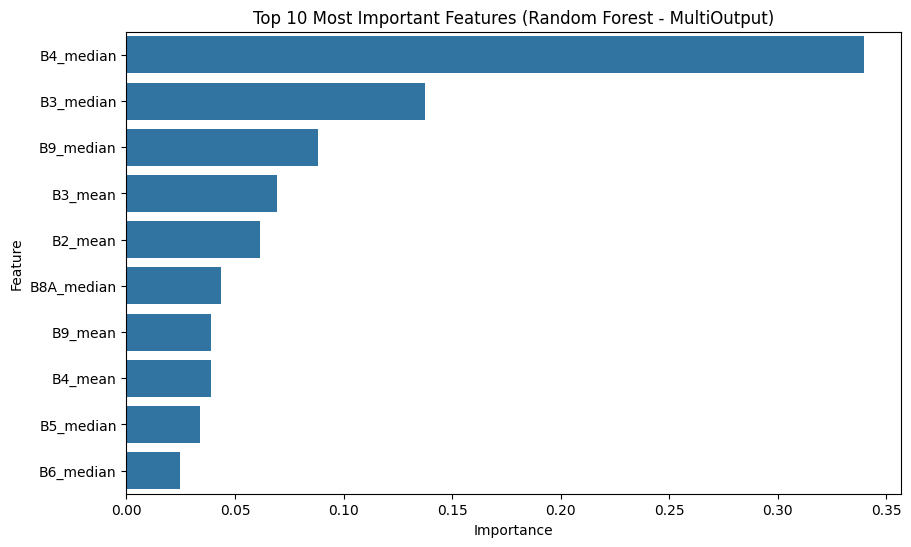

       Feature  Importance
7    B4_median    0.339877
5    B3_median    0.137521
23   B9_median    0.088006
4      B3_mean    0.069537
2      B2_mean    0.061729
19  B8A_median    0.043527
22     B9_mean    0.039091
6      B4_mean    0.038729
9    B5_median    0.033716
11   B6_median    0.024654
3    B2_median    0.024278
1    B1_median    0.019108
21   B8_median    0.015101
0      B1_mean    0.012270
10     B6_mean    0.010676
18    B8A_mean    0.010507
15  B12_median    0.009332
20     B8_mean    0.004749
8      B5_mean    0.003976
14    B12_mean    0.003536
12    B11_mean    0.003036
16     B7_mean    0.002594
13  B11_median    0.002576
17   B7_median    0.001873


In [53]:
feature_names = X_train.columns
importances = models['Random Forest'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Most Important Features (Random Forest - MultiOutput)')
plt.show()

print(feature_importance_df)